# LIV Golf — Business Intelligence

Two core questions any sports business stakeholder would ask:

1. **Competitive Parity** — Does LIV's format produce genuine competition, or do 1–2 teams dominate?
2. **Star Player Delivery** — Did marquee signings (Rahm, Smith, DeChambeau…) actually maintain their elite performance on LIV?
3. **Event Excitement** — Are events producing close finishes and leaderboard drama?

**Data sources:**
- `team_event_results.csv`, `team_season_summary.csv` — from notebook 1
- `liv_player_valuation.csv` — estimated SG per player per LIV season
- `individual_yoy_statistics.csv` — PGA Tour SG history (pre-LIV baseline)
- `liv_event_results.csv` — round-by-round individual scores

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import seaborn as sns
from pathlib import Path
from scipy import stats

DATA_DIR   = Path('../02_player_dashboard/data')
TRACK_DIR  = Path('../04_team_analytics/01_performance_tracking')
VAL_CSV    = Path('../03_player_valuation/liv_player_valuation.csv')
PGA_CSV    = Path('../../PGA_Prediction_Tools/data/raw/individual_yoy_statistics.csv')
OUT_DIR    = Path('.')

TEAM_COLORS = {
    'Crushers GC':          '#e74c3c',
    'Legion XIII':          '#8e44ad',
    'RangeGoats GC':        '#27ae60',
    'Torque GC':            '#f39c12',
    'HyFlyers GC':          '#2980b9',
    'Ripper GC':            '#16a085',
    'Cleeks Golf Club':     '#2c3e50',
    'Smash GC':             '#c0392b',
    'Majesticks Golf Club': '#7f8c8d',
    'Fireballs GC':         '#e67e22',
    'Southern Guards GC':   '#1abc9c',
    'Korean Golf Club':     '#3498db',
    '4Aces GC':             '#f1c40f',
    'Wild Card':            '#bdc3c7',
}
SHORT_NAMES = {
    'Crushers GC': 'Crushers', 'Legion XIII': 'Legion XIII',
    'RangeGoats GC': 'RangeGoats', 'Torque GC': 'Torque',
    'HyFlyers GC': 'HyFlyers', 'Ripper GC': 'Ripper',
    'Cleeks Golf Club': 'Cleeks', 'Smash GC': 'Smash',
    'Majesticks Golf Club': 'Majesticks', 'Fireballs GC': 'Fireballs',
    'Southern Guards GC': 'Southern Guards', 'Korean Golf Club': 'Korean GC',
    '4Aces GC': '4Aces', 'Wild Card': 'Wild Card',
}

plt.rcParams.update({
    'figure.facecolor': '#0e0e1a', 'axes.facecolor': '#0e0e1a',
    'axes.edgecolor': '#444', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'text.color': 'white', 'grid.color': '#333',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
})
print('Setup complete.')

Setup complete.


## Load data

In [2]:
ss  = pd.read_csv(TRACK_DIR / 'team_season_summary.csv')
te  = pd.read_csv(TRACK_DIR / 'team_event_results.csv')
val = pd.read_csv(VAL_CSV)
ev  = pd.read_csv(DATA_DIR / 'liv_event_results.csv')
pga = pd.read_csv(PGA_CSV, low_memory=False)

# Clean event results
ev['year'] = ev['year'].astype(int)
for col in ['R1','R2','R3']:
    ev[col] = pd.to_numeric(ev[col], errors='coerce')

# Full seasons only (>= 10 events)
full_seasons = ss.groupby('year')['events'].max()
full_yrs = full_seasons[full_seasons >= 10].index.tolist()

print(f'Full seasons: {sorted(full_yrs)}')
print(f'Team event records: {len(te)}')
print(f'Player event records: {len(ev)}')

Full seasons: [2023, 2024, 2025]
Team event records: 562
Player event records: 2467


---
# Part 1 — Competitive Parity

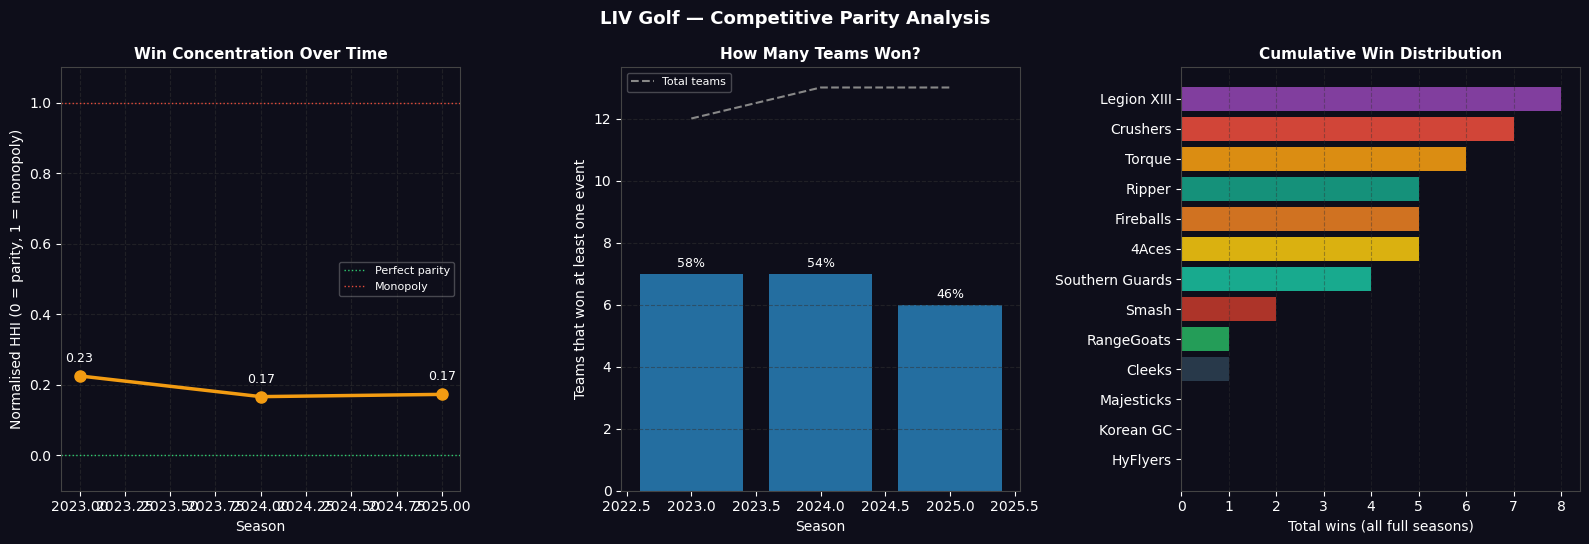

 year      hhi  hhi_norm  unique_winners  n_teams  total_events
 2023 0.289941  0.225390               7       12            13
 2024 0.230769  0.166667               7       13            13
 2025 0.236686  0.173077               6       13            13


In [3]:
# ── HHI of wins per season ────────────────────────────────────────────────────
# HHI = sum(win_share^2). Perfect parity = 1/N_teams. Monopoly = 1.
# Normalised HHI: (HHI - 1/N) / (1 - 1/N)  →  0 = perfect parity, 1 = monopoly

hhi_rows = []
for yr in sorted(full_yrs):
    yr_ss = ss[ss['year'] == yr]
    total_events = yr_ss['events'].max()
    n_teams = len(yr_ss)
    win_shares = yr_ss['wins'] / total_events
    hhi = (win_shares ** 2).sum()
    hhi_norm = (hhi - 1/n_teams) / (1 - 1/n_teams)
    unique_winners = (yr_ss['wins'] > 0).sum()
    hhi_rows.append({
        'year': yr, 'hhi': hhi, 'hhi_norm': hhi_norm,
        'unique_winners': unique_winners,
        'n_teams': n_teams, 'total_events': total_events,
    })

hhi_df = pd.DataFrame(hhi_rows)

# ── Win distribution ──────────────────────────────────────────────────────────
win_dist = (
    ss[ss['year'].isin(full_yrs)]
    .groupby('team')['wins'].sum()
    .sort_values(ascending=True)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# Left: HHI trend
ax = axes[0]
ax.plot(hhi_df['year'], hhi_df['hhi_norm'], color='#f39c12',
        linewidth=2.5, marker='o', markersize=8)
for _, row in hhi_df.iterrows():
    ax.annotate(f"{row['hhi_norm']:.2f}",
                (row['year'], row['hhi_norm']),
                textcoords='offset points', xytext=(0, 10), fontsize=9, ha='center')
ax.axhline(0, color='#2ecc71', linewidth=1, linestyle=':', label='Perfect parity')
ax.axhline(1, color='#e74c3c', linewidth=1, linestyle=':', label='Monopoly')
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel('Season')
ax.set_ylabel('Normalised HHI (0 = parity, 1 = monopoly)')
ax.set_title('Win Concentration Over Time', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(True)

# Middle: unique winners per season
ax = axes[1]
bars = ax.bar(hhi_df['year'], hhi_df['unique_winners'],
              color='#2980b9', edgecolor='none', alpha=0.85)
ax.plot(hhi_df['year'], hhi_df['n_teams'], color='#888',
        linewidth=1.5, linestyle='--', label='Total teams')
for bar, row in zip(bars, hhi_df.itertuples()):
    pct = row.unique_winners / row.n_teams
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{pct:.0%}', ha='center', fontsize=9)
ax.set_xlabel('Season')
ax.set_ylabel('Teams that won at least one event')
ax.set_title('How Many Teams Won?', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(axis='y')

# Right: cumulative win distribution
ax = axes[2]
colors = [TEAM_COLORS.get(t, '#888') for t in win_dist['team']]
labels = [SHORT_NAMES.get(t, t) for t in win_dist['team']]
ax.barh(labels, win_dist['wins'], color=colors, edgecolor='none', alpha=0.9)
ax.set_xlabel('Total wins (all full seasons)')
ax.set_title('Cumulative Win Distribution', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.4)

fig.suptitle('LIV Golf — Competitive Parity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'parity_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(hhi_df.to_string(index=False))

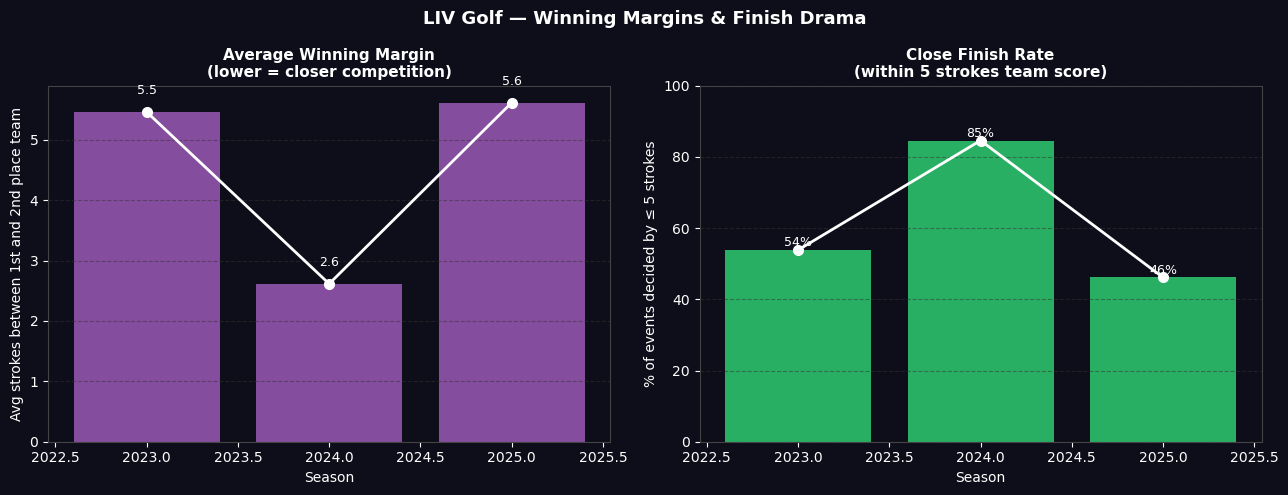

 year  avg_margin  close_finish_rate  n_events
 2023    5.461538           0.538462        13
 2024    2.615385           0.846154        13
 2025    5.615385           0.461538        13


In [4]:
# ── Margin of victory & close finish rate ────────────────────────────────────
# Margin = winning team score minus runner-up team score (negative = closer)
margins = []
for event_slug, grp in te.groupby('event_slug'):
    grp_sorted = grp.sort_values('event_rank')
    if len(grp_sorted) < 2:
        continue
    winner  = grp_sorted.iloc[0]
    runnerup = grp_sorted.iloc[1]
    margin = winner['team_score'] - runnerup['team_score']   # negative: winner scored lower
    margins.append({
        'event_slug':  event_slug,
        'year':        winner['year'],
        'winner':      winner['team'],
        'margin_strokes': abs(margin),   # absolute strokes between 1st and 2nd
    })

margins_df = pd.DataFrame(margins)
margins_df = margins_df[margins_df['year'].isin(full_yrs)]

# Per-season stats
season_margins = margins_df.groupby('year').agg(
    avg_margin=('margin_strokes', 'mean'),
    close_finish_rate=('margin_strokes', lambda x: (x <= 5).mean()),
    n_events=('margin_strokes', 'count'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: avg margin of victory per season
ax = axes[0]
ax.bar(season_margins['year'], season_margins['avg_margin'],
       color='#9b59b6', edgecolor='none', alpha=0.85)
ax.plot(season_margins['year'], season_margins['avg_margin'],
        color='white', linewidth=2, marker='o', markersize=7)
for _, row in season_margins.iterrows():
    ax.text(row['year'], row['avg_margin'] + 0.3, f"{row['avg_margin']:.1f}",
            ha='center', fontsize=9)
ax.set_xlabel('Season')
ax.set_ylabel('Avg strokes between 1st and 2nd place team')
ax.set_title('Average Winning Margin\n(lower = closer competition)', fontsize=11, fontweight='bold')
ax.grid(axis='y')

# Right: close finish rate (≤ 5 strokes)
ax = axes[1]
ax.bar(season_margins['year'], season_margins['close_finish_rate'] * 100,
       color='#2ecc71', edgecolor='none', alpha=0.85)
ax.plot(season_margins['year'], season_margins['close_finish_rate'] * 100,
        color='white', linewidth=2, marker='o', markersize=7)
for _, row in season_margins.iterrows():
    ax.text(row['year'], row['close_finish_rate'] * 100 + 1,
            f"{row['close_finish_rate']:.0%}", ha='center', fontsize=9)
ax.set_xlabel('Season')
ax.set_ylabel('% of events decided by ≤ 5 strokes')
ax.set_title('Close Finish Rate\n(within 5 strokes team score)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y')

fig.suptitle('LIV Golf — Winning Margins & Finish Drama', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'margins_and_drama.png', dpi=150, bbox_inches='tight')
plt.show()
print(season_margins.to_string(index=False))

In [ ]:
# ── Does the pre-season SG favourite always win? ──────────────────────────────
# Define favourite as team with highest est_sg_total_mean entering each season

fav_rows = []
for yr in sorted(full_yrs):
    # Use previous season's SG profile as pre-season expectation
    prev_yr = yr - 1
    prev_val = val[(val['season'] == prev_yr) & val['team'].notna() & (val['team'] != '')]
    if prev_val.empty:
        # For 2022, use 2022 itself (no prior LIV data)
        prev_val = val[(val['season'] == yr) & val['team'].notna() & (val['team'] != '')]
    team_sg = prev_val.groupby('team')['est_sg_total'].mean().reset_index()
    if team_sg.empty:
        continue
    favourite = team_sg.loc[team_sg['est_sg_total'].idxmax(), 'team']
    fav_sg    = team_sg['est_sg_total'].max()

    yr_ss = ss[ss['year'] == yr]
    actual_winner = yr_ss.loc[yr_ss['wins'].idxmax(), 'team'] if yr_ss['wins'].max() > 0 else None
    fav_wins = yr_ss[yr_ss['team'] == favourite]['wins'].sum() if favourite in yr_ss['team'].values else 0
    fav_rank  = yr_ss[yr_ss['team'] == favourite]['avg_rank'].values[0] if favourite in yr_ss['team'].values else np.nan

    fav_rows.append({
        'year': yr,
        'favourite': SHORT_NAMES.get(favourite, favourite),
        'fav_sg': fav_sg,
        'actual_champion': SHORT_NAMES.get(actual_winner, actual_winner),
        'fav_wins': fav_wins,
        'fav_avg_rank': fav_rank,
        'favourite_won_title': favourite == actual_winner,
    })

fav_df = pd.DataFrame(fav_rows)
print('=== Pre-Season SG Favourite vs Actual Champion ===')
print(fav_df.to_string(index=False))
print(f'\nFavourite won the season: {fav_df["favourite_won_title"].sum()}/{len(fav_df)} seasons')

---
# Part 2 — Star Player Delivery

In [6]:
# ── Build pre-LIV PGA baseline for each player ───────────────────────────────
# For each LIV player: find their last 1-2 PGA seasons before joining

first_liv_season = val.groupby('playerName')['season'].min().to_dict()

pga_baselines = []
for player, first_yr in first_liv_season.items():
    row = pga[pga['playerName'] == player]
    if row.empty:
        continue
    row = row.iloc[0]
    # Average of last 2 PGA seasons before joining
    pre_sgs = []
    for yr in [first_yr - 1, first_yr - 2]:
        col = f'{yr}_SG_Total_Avg'
        if col in pga.columns and pd.notna(row.get(col)):
            pre_sgs.append(float(row[col]))
    if pre_sgs:
        pga_baselines.append({
            'playerName':    player,
            'first_liv_yr':  first_yr,
            'pga_baseline':  np.mean(pre_sgs),
        })

baseline_df = pd.DataFrame(pga_baselines)

# ── Merge with LIV SG trajectory ─────────────────────────────────────────────
liv_sg = val[val['team'].notna() & (val['team'] != '')][['playerName','season','est_sg_total']].copy()

# Player-level: average est_sg across all LIV seasons
liv_avg = liv_sg.groupby('playerName')['est_sg_total'].mean().reset_index()
liv_avg.columns = ['playerName', 'liv_avg_sg']

star_df = baseline_df.merge(liv_avg, on='playerName', how='inner')
star_df['delta_sg'] = star_df['liv_avg_sg'] - star_df['pga_baseline']
star_df['verdict'] = star_df['delta_sg'].apply(
    lambda d: 'Improved' if d > 0.1 else ('Maintained' if d > -0.2 else 'Declined')
)

print(f'Players with both PGA baseline and LIV data: {len(star_df)}')
print(f'\nVerdict breakdown:')
print(star_df['verdict'].value_counts())
print(f'\nAverage SG delta: {star_df["delta_sg"].mean():+.3f}')
print(f'Median SG delta:  {star_df["delta_sg"].median():+.3f}')

Players with both PGA baseline and LIV data: 35

Verdict breakdown:
verdict
Declined      16
Improved      12
Maintained     7
Name: count, dtype: int64

Average SG delta: -0.101
Median SG delta:  -0.130


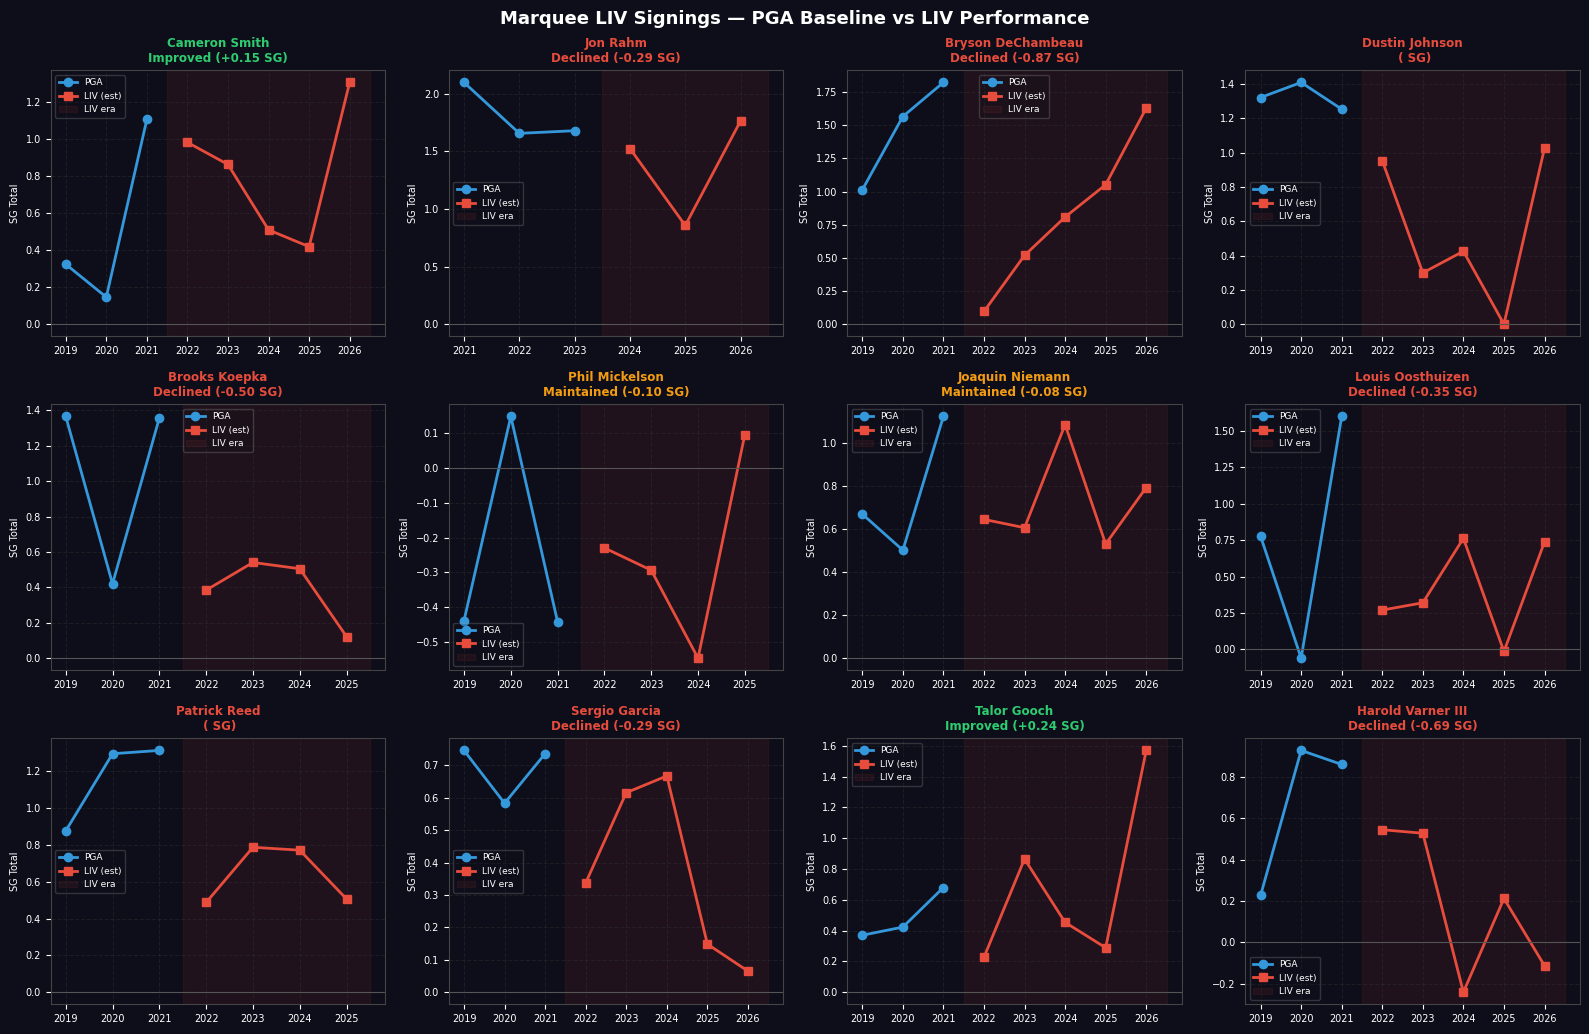

In [7]:
# ── Marquee signing spotlight ─────────────────────────────────────────────────
MARQUEE = [
    'Cameron Smith', 'Jon Rahm', 'Bryson DeChambeau', 'Dustin Johnson',
    'Brooks Koepka', 'Phil Mickelson', 'Joaquin Niemann', 'Louis Oosthuizen',
    'Patrick Reed', 'Sergio Garcia', 'Talor Gooch', 'Harold Varner III',
]

marquee_sg = []
for player in MARQUEE:
    row = pga[pga['playerName'] == player]
    first_yr = first_liv_season.get(player)
    if row.empty or first_yr is None:
        continue
    row = row.iloc[0]

    # Build full trajectory: PGA years + LIV years
    traj = []
    for yr in range(first_yr - 3, first_yr):   # 3 PGA seasons pre-LIV
        col = f'{yr}_SG_Total_Avg'
        if col in pga.columns and pd.notna(row.get(col)):
            traj.append({'playerName': player, 'year': yr, 'sg': float(row[col]), 'tour': 'PGA'})

    liv_yrs = val[val['playerName'] == player][['season','est_sg_total']].dropna()
    for _, lrow in liv_yrs.iterrows():
        traj.append({'playerName': player, 'year': int(lrow['season']),
                     'sg': lrow['est_sg_total'], 'tour': 'LIV'})

    marquee_sg.extend(traj)

marquee_df = pd.DataFrame(marquee_sg)

# ── Plot trajectory grid ──────────────────────────────────────────────────────
players_plot = [p for p in MARQUEE if p in marquee_df['playerName'].unique()]
ncols = 4
nrows = int(np.ceil(len(players_plot) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes_flat = axes.flatten()

for i, player in enumerate(players_plot):
    ax = axes_flat[i]
    pdf = marquee_df[marquee_df['playerName'] == player].sort_values('year')
    pga_pts = pdf[pdf['tour'] == 'PGA']
    liv_pts = pdf[pdf['tour'] == 'LIV']

    if not pga_pts.empty:
        ax.plot(pga_pts['year'], pga_pts['sg'], color='#3498db',
                linewidth=2, marker='o', markersize=6, label='PGA')
    if not liv_pts.empty:
        ax.plot(liv_pts['year'], liv_pts['sg'], color='#e74c3c',
                linewidth=2, marker='s', markersize=6, label='LIV (est)')

    # Shade LIV era
    first_yr = first_liv_season.get(player, None)
    if first_yr:
        ax.axvspan(first_yr - 0.5, pdf['year'].max() + 0.5,
                   alpha=0.08, color='#e74c3c', label='LIV era')
    ax.axhline(0, color='#555', linewidth=0.8)

    delta_row = star_df[star_df['playerName'] == player]
    delta_str = f"{delta_row['delta_sg'].values[0]:+.2f}" if not delta_row.empty else ''
    verdict   = delta_row['verdict'].values[0] if not delta_row.empty else ''
    verdict_color = '#2ecc71' if verdict == 'Improved' else ('#f39c12' if verdict == 'Maintained' else '#e74c3c')

    ax.set_title(f'{player}\n{verdict} ({delta_str} SG)',
                 fontsize=8.5, fontweight='bold', color=verdict_color)
    ax.set_ylabel('SG Total', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=6.5, framealpha=0.2)

for j in range(len(players_plot), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Marquee LIV Signings — PGA Baseline vs LIV Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'star_player_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

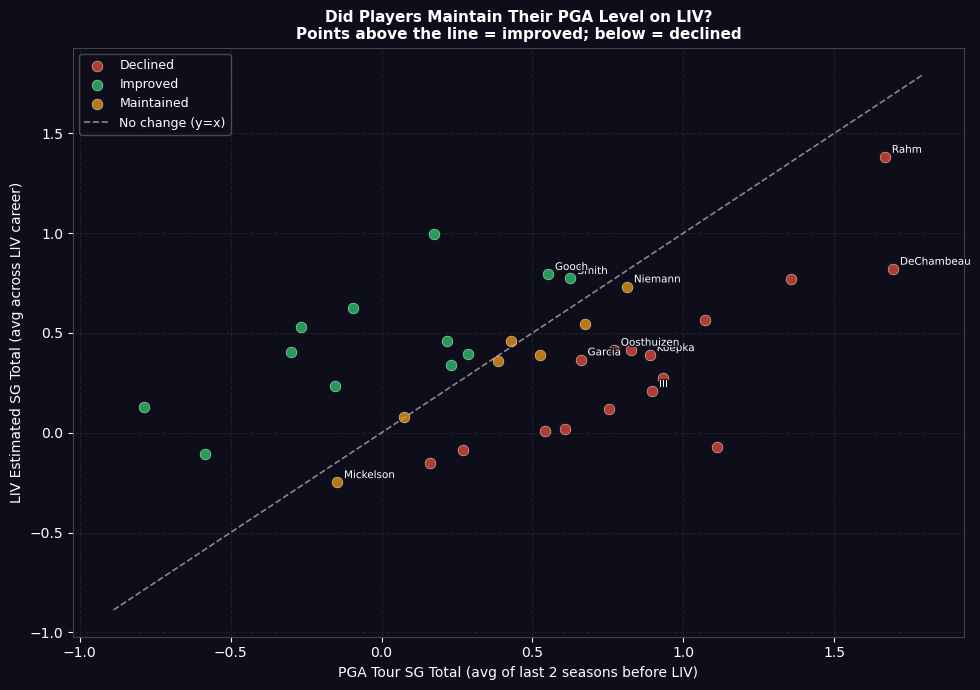

=== Avg SG delta by joining cohort ===
               pga_baseline  liv_avg_sg  delta_sg
cohort                                           
Class of 2022         0.466       0.350    -0.116
Class of 2023         0.324       0.042    -0.282
Class of 2024         0.919       0.894    -0.025
Class of 2026         0.349       0.693     0.344


In [8]:
# ── Field-wide: PGA baseline vs LIV avg SG (scatter) ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

verdict_colors = {'Improved': '#2ecc71', 'Maintained': '#f39c12', 'Declined': '#e74c3c'}

for verdict, grp in star_df.groupby('verdict'):
    ax.scatter(grp['pga_baseline'], grp['liv_avg_sg'],
               color=verdict_colors[verdict], s=60, alpha=0.75,
               edgecolors='white', linewidth=0.4, label=verdict, zorder=3)

# Label marquee players
for _, row in star_df[star_df['playerName'].isin(MARQUEE)].iterrows():
    ax.annotate(
        row['playerName'].split()[-1],   # last name only
        (row['pga_baseline'], row['liv_avg_sg']),
        textcoords='offset points', xytext=(5, 3), fontsize=7.5,
        path_effects=[pe.withStroke(linewidth=2, foreground='#0e0e1a')],
    )

# y = x reference line (no change)
lim_min = min(star_df['pga_baseline'].min(), star_df['liv_avg_sg'].min()) - 0.1
lim_max = max(star_df['pga_baseline'].max(), star_df['liv_avg_sg'].max()) + 0.1
ax.plot([lim_min, lim_max], [lim_min, lim_max], color='white',
        linewidth=1.2, linestyle='--', alpha=0.5, label='No change (y=x)')

ax.set_xlabel('PGA Tour SG Total (avg of last 2 seasons before LIV)')
ax.set_ylabel('LIV Estimated SG Total (avg across LIV career)')
ax.set_title('Did Players Maintain Their PGA Level on LIV?\n'
             'Points above the line = improved; below = declined',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(True)

plt.tight_layout()
plt.savefig(OUT_DIR / 'star_delivery_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary by cohort (join year)
cohort = star_df.copy()
cohort['cohort'] = cohort['first_liv_yr'].map(lambda y: f'Class of {y}')
print('=== Avg SG delta by joining cohort ===')
print(cohort.groupby('cohort')[['pga_baseline','liv_avg_sg','delta_sg']].mean().round(3))

---
# Part 3 — Event Excitement Index

In [9]:
# ── Individual leaderboard volatility ────────────────────────────────────────
# Round-by-round score spread and cumulative score variance per event

ev_clean = ev[ev['year'].isin(full_yrs)].copy()
ev_clean['total_to_par'] = pd.to_numeric(ev_clean['total_to_par'], errors='coerce')

# Per-event metrics
event_excitement = []
for (slug, yr), grp in ev_clean.groupby(['event_slug', 'year']):
    # Score spread: std dev of final individual scores
    scores = grp['total_to_par'].dropna()
    if len(scores) < 10:
        continue

    # Round-by-round spread (how compressed or spread are scores each round)
    r1_std = grp['R1'].dropna().std()
    r2_std = grp['R2'].dropna().std()
    r3_std = grp['R3'].dropna().std()

    # Final spread: IQR of total scores (robust to outliers)
    q75, q25 = np.nanpercentile(scores, [75, 25])
    iqr = q75 - q25

    # Team competition margin for this event
    event_teams = te[(te['event_slug'] == slug)].sort_values('event_rank')
    if len(event_teams) >= 2:
        team_margin = abs(event_teams.iloc[0]['team_score'] - event_teams.iloc[1]['team_score'])
    else:
        team_margin = np.nan

    event_name = grp['event_name'].iloc[0] if 'event_name' in grp.columns else slug
    event_excitement.append({
        'event_slug':   slug,
        'event_name':   event_name,
        'year':         yr,
        'score_spread': scores.std(),
        'score_iqr':    iqr,
        'r1_std':       r1_std,
        'r2_std':       r2_std,
        'r3_std':       r3_std,
        'team_margin':  team_margin,
        'n_players':    len(scores),
    })

exc_df = pd.DataFrame(event_excitement)

# Composite excitement score: low team margin + high individual score spread
# Normalise both to 0-1 then combine (invert margin: lower = more exciting)
exc_df['margin_norm'] = 1 - (exc_df['team_margin'] - exc_df['team_margin'].min()) / \
                            (exc_df['team_margin'].max() - exc_df['team_margin'].min())
exc_df['spread_norm'] = (exc_df['score_spread'] - exc_df['score_spread'].min()) / \
                        (exc_df['score_spread'].max() - exc_df['score_spread'].min())
exc_df['excitement_index'] = 0.6 * exc_df['margin_norm'] + 0.4 * exc_df['spread_norm']

print(f'Events analysed: {len(exc_df)}')
print('\nTop 10 most exciting events:')
print(exc_df.nlargest(10, 'excitement_index')[
    ['event_name','year','team_margin','score_spread','excitement_index']
].to_string(index=False, float_format=lambda x: f'{x:.2f}'))
print('\nTop 10 least exciting events:')
print(exc_df.nsmallest(10, 'excitement_index')[
    ['event_name','year','team_margin','score_spread','excitement_index']
].to_string(index=False, float_format=lambda x: f'{x:.2f}'))

Events analysed: 39

Top 10 most exciting events:
      event_name  year  team_margin  score_spread  excitement_index
     Tucson 2023  2023         5.00         17.06              0.77
         Uk 2024  2024         0.00          5.48              0.64
    Houston 2024  2024         0.00          5.15              0.63
         Dc 2023  2023         0.00          5.14              0.63
    Orlando 2023  2023         0.00          5.00              0.63
    Chicago 2025  2025         0.00          4.55              0.61
 Greenbrier 2024  2024         1.00          5.69              0.60
  Singapore 2024  2024         1.00          5.52              0.60
Mexico City 2025  2025         2.00          6.99              0.60
    Chicago 2024  2024         1.00          5.11              0.58

Top 10 least exciting events:
       event_name  year  team_margin  score_spread  excitement_index
  Valderrama 2023  2023        13.00          6.36              0.07
    Mayakoba 2023  2023        13

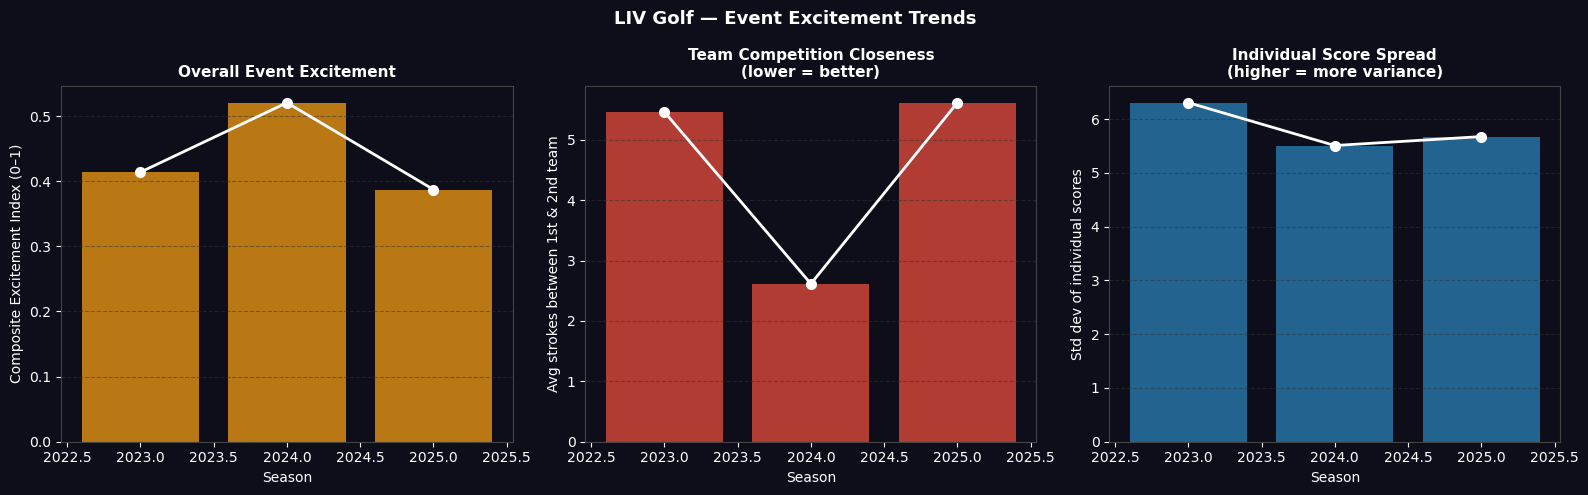

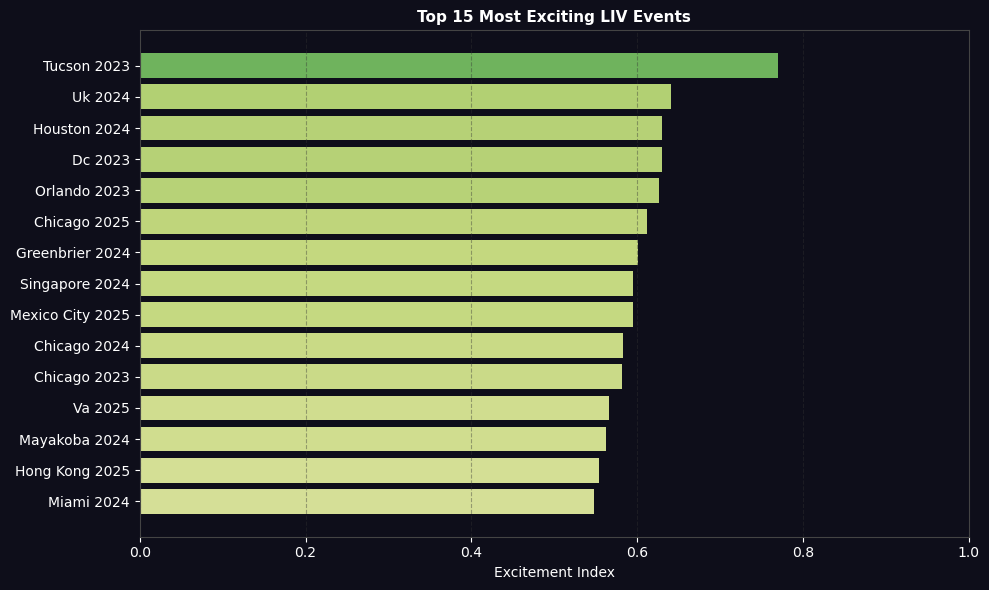

In [10]:
# ── Excitement trend + season avg ─────────────────────────────────────────────
season_exc = exc_df.groupby('year').agg(
    avg_excitement=('excitement_index', 'mean'),
    avg_team_margin=('team_margin', 'mean'),
    avg_score_spread=('score_spread', 'mean'),
    n_events=('excitement_index', 'count'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, ylabel, title, color) in zip(axes, [
    ('avg_excitement',   'Composite Excitement Index (0–1)', 'Overall Event Excitement', '#f39c12'),
    ('avg_team_margin',  'Avg strokes between 1st & 2nd team', 'Team Competition Closeness\n(lower = better)', '#e74c3c'),
    ('avg_score_spread', 'Std dev of individual scores', 'Individual Score Spread\n(higher = more variance)', '#2980b9'),
]):
    ax.bar(season_exc['year'], season_exc[col], color=color, edgecolor='none', alpha=0.75)
    ax.plot(season_exc['year'], season_exc[col], color='white',
            linewidth=2, marker='o', markersize=7)
    ax.set_xlabel('Season')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='y')

fig.suptitle('LIV Golf — Event Excitement Trends', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'event_excitement.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Top 15 most exciting events (all time) ────────────────────────────────────
top_events = exc_df.nlargest(15, 'excitement_index').copy()
top_events['label'] = top_events['event_name'].str.replace(r'\s+\d{4}.*', '', regex=True).str[:20] \
                    + ' ' + top_events['year'].astype(str)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [plt.cm.RdYlGn(x) for x in top_events['excitement_index']]
ax.barh(top_events['label'][::-1].values, top_events['excitement_index'][::-1].values,
        color=colors[::-1], edgecolor='none', alpha=0.9)
ax.set_xlabel('Excitement Index')
ax.set_title('Top 15 Most Exciting LIV Events', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / 'top_exciting_events.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── Save outputs ──────────────────────────────────────────────────────────────
hhi_df.to_csv(OUT_DIR / 'parity_hhi.csv', index=False)
star_df.to_csv(OUT_DIR / 'star_delivery.csv', index=False)
exc_df.to_csv(OUT_DIR / 'event_excitement.csv', index=False)

print('Saved: parity_hhi.csv, star_delivery.csv, event_excitement.csv')
print()
print('=== Key takeaways ===')
print(f'Parity:   HHI normalised range {hhi_df["hhi_norm"].min():.2f}–{hhi_df["hhi_norm"].max():.2f} across seasons')
print(f'          {hhi_df["unique_winners"].mean():.1f} teams won per season on average')
print(f'Stars:    {(star_df["verdict"]=="Declined").sum()}/{len(star_df)} players declined vs PGA baseline')
print(f'          Mean SG delta = {star_df["delta_sg"].mean():+.3f}')
print(f'Margins:  Avg winning margin = {margins_df["margin_strokes"].mean():.1f} strokes')
print(f'          Close finishes (≤5 strokes) = {(margins_df["margin_strokes"]<=5).mean():.0%} of events')

Saved: parity_hhi.csv, star_delivery.csv, event_excitement.csv

=== Key takeaways ===
Parity:   HHI normalised range 0.17–0.23 across seasons
          6.7 teams won per season on average
Stars:    16/35 players declined vs PGA baseline
          Mean SG delta = -0.101
Margins:  Avg winning margin = 4.6 strokes
          Close finishes (≤5 strokes) = 62% of events
